### **ACID - PART 3 - Control image quality**

**Author:** Alessandro Ulivi (alessandro.ulivi.89@gmail.com)

**Last update (yyyy/mm/dd):** 2026/04/27


## **---------------------------**

### Import required modules

Run the following cell.

Don't modify the following cell.

In [1]:
# Import required modules
import datetime
import os
from pathlib import Path
import numpy as np
import pandas as pd
import tifffile
import napari
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter
from skimage.morphology import disk
from acid.utils.listdirNHF import listdirNHF
from acid.utils.get_defaults import default_file_name
from acid.utils.fov_axis_utils import get_fov_ch_shape
# from acid.image_quality_control.measure_plls import compute_plls
# from acid.image_quality_control.measure_percentile_fraction import fraction_in_extreme_percentiles
from acid.image_quality_control.measure_mean_over_std import mean_over_std
from acid.image_quality_control.measure_percentil_fraction_stat import measure_percentile_stat
from acid.image_measurement.measure_glob_image_stat import axis_image_stat, normalized_intensity_skewness
from acid.image_quality_control.display_qc import display_high_low_qc, display_qc, plot_qc_by_channel_condition
from acid.image_quality_control.flag_column import add_flag_column



### Specify the paths to input and output data directories - specify hyperparameters

Run the following cell.

Some parts of the following cell should be modified. The parts NOT to modify are under the line ""--- --- --- DON'T MODIFY THE FOLLOWING LINES --- --- ---"

In [2]:
# indicate the path to the directory storing the metadata file - NOTE: this is expected to be the metadata_df saved
# from part1 notebook
metadata_directory = r"Z:\AlessandroUlivi_Data\projects\ACID\data\proc\proc_metadata"
# metadata_directory = r"C:\Users\aless\OneDrive\Desktop\Ale\lab\CIID_IDIP\projects\ACID\data\proc\proc_metadata"

# indicate the path to the directory storing the fields of view
fov_directory = r"Z:\AlessandroUlivi_Data\projects\ACID\data\proc\fov"
# fov_directory = r"C:\Users\aless\OneDrive\Desktop\Ale\lab\CIID_IDIP\projects\ACID\data\proc\fov"

## # indicate the path to the directory where outputs will be saved
# the following options are possible:
# 1) write the full path to the directory where outputs will be saved
# 2) write "default" or any other version with a uppercase letter (e.g. "Default")
# 3) leave an empty string: ""
# 4) write None (NOTE that this is not a string, there are no "", aka it is not "None")
# Options 2,3 and 4 will lead to the same behavior: the outputs will be saved in the same directory as the metadata file.
output_directory = "Z:\AlessandroUlivi_Data\projects\ACID\data\proc\proc_metadata"
# output_directory = r"C:\Users\aless\OneDrive\Desktop\Ale\lab\CIID_IDIP\projects\ACID\develop\260108_QCs"


# name of the metadata file - NOTE: this is expected to be the metadata_df saved
# from part2 notebook
# the following options are possible:
# 1) write the full name (extension included) of the csv file
# 2) write "default" or any other version with a uppercase letter (e.g. "Default")
# 3) leave an empty string: ""
# 4) write None (NOTE that this is not a string, there are no "", aka it is not "None")
# Options 2,3 and 4 will lead to the same behavior: the most recently saved csv file will be used.
# By default, the timestap of the last file modification is used. As an alternative it is possible to use the
# date saved in the name (change below parameter metadata_from_file_name to True -
# see utils.get_defaults.default_file_name documentation).
# metadata_file_name = "default"
metadata_file_name = "20251211_ACID_metadata_part_2.csv"

# indicate whether to save the graphs generated in this notebook
save_graphs = True

# graph saving directory - this is the directory where the graphs generated in this notebook will be saved
# graph_saving_directory = r"Z:\AlessandroUlivi_Data\projects\ACID\develop\260109_QCs\graphs"
graph_saving_directory = r"Z:\AlessandroUlivi_Data\projects\ACID\develop\260421_QCs"



# ""--- --- --- DON'T MODIFY THE FOLLOWING LINES --- --- ---"

# # --- parameters to flag fields of view which don't pass quality controls ---
flag_column="flag"
flag_value=1
ok_value=0

# # --- parameters to select the train set ---
# indicate the name of the column indicating whether the row belongs to train or test set
is_train_column="is_train"

# indicate the value signalling that a row (aka a field of view) belongs to the train set
train_val=1

# # --- parameters used for importing the default metadata dataframe ---
# Indicate the part of the file name to use to select files into metadata_directory to be used for selecting the default
# file
default_metadata_file_target = ".csv"
default_metadata_file_exclude = None

# Indicate whether to extract the date information from the file name when selecting the default file
# If False, the date will be extracted from the file's last modified timestamp, if True, from the file name.
# If from_file_name is True, the parameters *_default_separator and *_default_date_position
# should be used to indicate, respectively the separator to use for splitting the file name into tokens and
# the position of the token containing the date information. In addition, the date format used to include the date in the file name
# should be indicated using the parameters *_default_date_format.
# For example, if metadata_from_file_name is True, and the file name is "251126_plate_layout.csv",
# "_" is used as separator, 0 as date position, and '%Y%m%d' as date format.
# Ref to utils.get_defaults.default_file_name for more details.
metadata_from_file_name = False

# separator - used to split the file name and extract the information token with the date
# if metadata_from_file_name is True
metadata_default_separator = '_'

# date position - the position of the date information token after splitting the file name using file_name_separator (above)
# used if metadata_from_file_name is True
metadata_default_date_position = 0

# date format - the format used for including the date in the file name to be opened by default
# used if metadata_from_file_name is True
metadata_default_date_format='%Y%m%d'

# reverse - if True, the file with the most recent date will be returned by default - if False, the opposite
metadata_default_reverse = True


# --- parameters for quality control calculation ---
# channel axis to be passed to quality control functions in order to calculate quality control
# values of individual channels
channel_axis = 0

# field of view column name in the metadata dataframe
fov_column_name = "ome_tif_file_name"

# null value to be used to fill quality control metrics columns when they can't be calculated
null_value = np.nan

# plls column name
plls_column_name = "plls"

# # low percentile value to be used for calculating the extreme intensity percentile fraction
# # quality control metric
# low_percentile = 0.1

# # high percentile value to be used for calculating the extreme intensity percentile fraction
# # quality control metric
# high_percentile = 99.9

# # stat to calculate on the top and bottom percentile pixels
# stat = 'mean'

# # median smoothing
median_smooth = True
median_size = 3
median_kwargs_axes_name = 'axes'

normalize=True,
ravel_kwargs={}
mask=None


# # bottom percentile fraction column name
# bottom_perc_fract_column_name = f"bottom_percentile_fraction_{stat}"

# # top percentile fraction column name
# top_perc_fract_column_name = f"top_percentile_fraction_{stat}"

# skewness column name
skewness_column_name = "normalized_intensity_skewness"

# mean over std column name
mean_over_std_column_name = "mean_over_std"


# --- parameters for quality control visualization ---
# well column name for quality control visualization
well_clm = "well"

# experiment column name for quality control visualization
experiment_clm = "experiment"

# column name for the x-axis in quality control plots per well
qc_well_x_axis_column_name = "well"

# column name for the x-axis in quality control plots per experiment
qc_experiment_x_axis_column_name = "experiment"



# --- parameters for metadata dataframe updating ---
# channel separator used when saving multiple channel measurements into single dataframe columns
ch_measurement_separator = '-'


# --- parameters for file saving ---
# separator used for saved file names
save_file_name_separator = '_'

# project
project_name = "ACID"

# include indexes when saving pandas dataframes as csv files
save_csv_index = False # if False, the index will not be saved as a separate column in the csv file

# metadata saving date format
metadata_date_format = '%Y%m%d'

# metadata savingword
metadata_savingword = "metadata"

# metadata file suffix
metadata_file_suffix = f"part{save_file_name_separator}3.csv"

# hyperparameters saving date format
hyperparameters_date_format = '%Y%m%d-%H%M%S'

# hyperparameters savingword
hyperparameters_savingword = "hyperparameters"

# hyperparameters file suffix
hyperparameters_file_suffix = f"part{save_file_name_separator}3.csv"

# qc graphs saving date format
qc_graphs_date_format = '%Y%m%d'

# qc graphs suffix
qc_graphs_suffix = f".png"

# plls per channel savingword
plls_per_channel_savingword = f"plls{save_file_name_separator}ch"

# plls per channel and experiment savingword
plls_per_channel_experiment_savingword = f"plls{save_file_name_separator}ch{save_file_name_separator}exp"

# plls per channel and well savingword
plls_per_channel_well_savingword = f"plls{save_file_name_separator}ch{save_file_name_separator}well"

# percentile fraction per channel savingword
perc_fract_per_channel_savingword = f"perc{save_file_name_separator}fract{save_file_name_separator}ch"

# percentile fraction per channel and experiment savingword
perc_fract_per_ch_exp_savingword = f"perc{save_file_name_separator}fract{save_file_name_separator}ch{save_file_name_separator}exp"

# percentile fraction per channel and well savingword
perc_fract_per_ch_well_savingword = f"perc{save_file_name_separator}fract{save_file_name_separator}ch{save_file_name_separator}well"

# mean over std per channel savingword
mean_over_std_per_channel_savingword = f"mean{save_file_name_separator}over{save_file_name_separator}std{save_file_name_separator}ch"

# mean over std per channel and experiment savingword
mean_over_std_per_ch_exp_savingword = f"mean{save_file_name_separator}over{save_file_name_separator}std{save_file_name_separator}ch{save_file_name_separator}exp"

# mean over std per channel and well savingword
mean_over_std_per_ch_well_savingword = f"mean{save_file_name_separator}over{save_file_name_separator}std{save_file_name_separator}ch{save_file_name_separator}well"


# --- parameters for saving secondary information ---
# indicate the name of the directory for saving secondary outputs -
# this directory is used to store the hyperparameters used per each run of the pipeline
secondary_output_directory = "secondary_output"
exist_ok = True # if the secondary output directory already exists, do not raise an error



<>:17: SyntaxWarning: invalid escape sequence '\A'
<>:17: SyntaxWarning: invalid escape sequence '\A'
C:\Users\Alessandro Ulivi\AppData\Local\Temp\ipykernel_4856\401078058.py:17: SyntaxWarning: invalid escape sequence '\A'
  output_directory = "Z:\AlessandroUlivi_Data\projects\ACID\data\proc\proc_metadata"


### Define output_directory: use default option is needed or the specified path

### Create secondary output directory if it doesn't exist - this directory is used to store the hyperparameters used per each run of the pipeline

Run the following cell.

Don't modify the following cell.

In [3]:
# check if using the default output_directory
if output_directory==None or output_directory.lower()=="default" or output_directory=="":

    print("Using the default output directory, which is the same as the metadata directory.")
    
    # if using the default output directory, set the output directory to be the same as the metadata directory
    output_directory = metadata_directory
else:
    # if not using the default output directory, ensure that it is a path
    output_directory = Path(output_directory).resolve() # ensure that the output directory is an absolute path

# create the path to secondary_output directory
secondary_output_path = os.path.join(os.getcwd(), secondary_output_directory)

# create the secondary_output directory if it doesn't exist
if not os.path.exists(secondary_output_path):
    os.makedirs(secondary_output_path, exist_ok=exist_ok)


#### Open the metadata dataframe - this is expected to be the output of part 2

Run the following cell.

Don't modify the following cell.

In [4]:

# check if using the default metadata data frame (the most recently saved)
if metadata_file_name==None or metadata_file_name.lower()=="default" or metadata_file_name=="":
    
    # import target files in the metadata_directory
    metadata_files = listdirNHF(metadata_directory,
                                target=default_metadata_file_target,
                                exclude=default_metadata_file_exclude)
    
    # get the default metadata file
    metadata_file_name = default_file_name(file_list=metadata_files,
                                           from_file_name=metadata_from_file_name,
                                           directory_path=metadata_directory,
                                           separator=metadata_default_separator,
                                           date_position=metadata_default_date_position,
                                           date_format=metadata_default_date_format,
                                           reverse=metadata_default_reverse)
    
    print(f"using {metadata_file_name} as default metadata file")


# open the metadata file
metadata_df_i = pd.read_csv(os.path.join(metadata_directory, metadata_file_name))

# copy metadata_df
metadata_df = metadata_df_i.copy()

# # display the metadata dataframe
# metadata_df



#### Select train data set - NOTE: the metadata_df is updated into a metadata_df which does not contain the test data

Run the following cell.

Don't modify the following cell.

In [5]:
# Select only the train set and update metadata_df
metadata_df = metadata_df[metadata_df[is_train_column] == train_val]

# assert proper selection of train set
assert metadata_df.shape[0] > 0, "No rows in metadata_df belong to the train set."
assert all(metadata_df[is_train_column] == train_val), "Not all rows in metadata_df belong to the train set."

# Display the metadata dataframe
metadata_df


,raw_file_name,scene_name,processing_date_yymmdd,ome_tif_file_name,location,microscope,objective,experiment,condition1,infectious_organism,...,size_c,size_z,size_y,physical_size_y,size_x,physical_size_x,dims_order,int_well,treatment,is_train
0,H7_DENV2_MOI1_30h_fixed_stained_well1.nd2,A1,251211,H7_DENV2_MOI1_30h_fixed_stained_well1_A07p2_A1...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.2,H7,DENV2,...,5,1,1024,0.325,1024,0.325,CYX,1,uninfected_nocpd,1
1,H7_DENV2_MOI1_30h_fixed_stained_well1.nd2,A2,251211,H7_DENV2_MOI1_30h_fixed_stained_well1_A07p2_A2...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.2,H7,DENV2,...,5,1,1024,0.325,1024,0.325,CYX,1,uninfected_nocpd,1
4,H7_DENV2_MOI1_30h_fixed_stained_well1.nd2,A5,251211,H7_DENV2_MOI1_30h_fixed_stained_well1_A07p2_A5...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.2,H7,DENV2,...,5,1,1024,0.325,1024,0.325,CYX,1,uninfected_nocpd,1
5,H7_DENV2_MOI1_30h_fixed_stained_well1.nd2,A6,251211,H7_DENV2_MOI1_30h_fixed_stained_well1_A07p2_A6...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.2,H7,DENV2,...,5,1,1024,0.325,1024,0.325,CYX,1,uninfected_nocpd,1
7,H7_DENV2_MOI1_30h_fixed_stained_well1.nd2,B7,251211,H7_DENV2_MOI1_30h_fixed_stained_well1_A07p2_B7...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.2,H7,DENV2,...,5,1,1024,0.325,1024,0.325,CYX,1,uninfected_nocpd,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1166,H7_DENV2_MOI1_40h_fixed_stained_well8.nd2,F3,251211,H7_DENV2_MOI1_40h_fixed_stained_well8_A07p4_F3...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.4,H7,DENV2,...,5,1,1024,0.325,1024,0.325,CYX,8,uninfected_JNJ_A07,1
1170,H7_DENV2_MOI1_40h_fixed_stained_well8.nd2,G2,251211,H7_DENV2_MOI1_40h_fixed_stained_well8_A07p4_G2...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.4,H7,DENV2,...,5,1,1024,0.325,1024,0.325,CYX,8,uninfected_JNJ_A07,1
1172,H7_DENV2_MOI1_40h_fixed_stained_well8.nd2,G4,251211,H7_DENV2_MOI1_40h_fixed_stained_well8_A07p4_G4...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.4,H7,DENV2,...,5,1,1024,0.325,1024,0.325,CYX,8,uninfected_JNJ_A07,1
1174,H7_DENV2_MOI1_40h_fixed_stained_well8.nd2,G6,251211,H7_DENV2_MOI1_40h_fixed_stained_well8_A07p4_G6...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.4,H7,DENV2,...,5,1,1024,0.325,1024,0.325,CYX,8,uninfected_JNJ_A07,1


H7_DENV2_MOI1_40h_fixed_stained_well2_A07p4_G1.ome.tif
(5, 1024, 1024)
{'axes': (1, 2)}


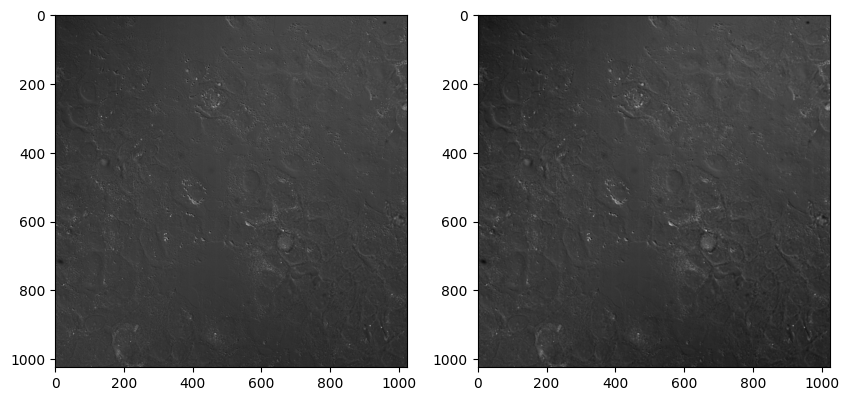

In [ ]:
# import matplotlib.pyplot as plt
# from random import choice
# from skimage.morphology import disk
# from skimage.filters import gaussian, median

# target_ch=4
# # guassian_sigma=1
# # footprint=disk(3)

# # target_field_name = "H7_DENV2_MOI1_30h_fixed_stained_well4_A07p2_F2.ome.tif"
# # # target_field_name = "H7_DENV2_MOI1_40h_fixed_stained_well4_A07p3_E5.ome.tif"
# # # target_field_name = "H7_DENV2_MOI1_40h_fixed_stained_well2_A07p4_A4.ome.tif"
# # target_field = tifffile.imread(os.path.join(fov_directory,target_field_name))
# # target_field_ch = target_field[target_ch,...]
# # # target_field_ch = gaussian(target_field_ch,sigma=guassian_sigma)
# # target_field_ch = median(target_field_ch, footprint)

# random_field_name = choice(list(metadata_df[fov_column_name]))
# # # random_field_name = "H7_DENV2_MOI1_40h_fixed_stained_well2_A07p4_G5.ome.tif"
# print(random_field_name)
# random_field = tifffile.imread(os.path.join(fov_directory,random_field_name))
# print(random_field.shape)
# # random_field_ch = random_field[target_ch,...]
# # # random_field_ch = gaussian(random_field_ch,sigma=guassian_sigma)
# # random_field_ch = median(random_field_ch, footprint)
# if median_smooth:
#         median_kwargs={median_kwargs_axes_name:tuple([c for c in range(len(random_field.shape)) if c != channel_axis])}
#         # median_kwargs={'axes':(0,1)}
#         print(median_kwargs)
#         smoothed_field_of_view = median_filter(random_field, size=median_size, **median_kwargs)



# # q=0.1
# # low_perc_target = np.percentile(target_field_ch,
# #                                 q=q)
# # low_perc_random = np.percentile(random_field_ch,
# #                                 q=q)

# # high_perc_target = np.percentile(target_field_ch,
# #                                  q=100-q)
# # high_perc_random = np.percentile(random_field_ch,
# #                                  q=100-q)


# fig,ax=plt.subplots(1,2, figsize=(10,8))
# # # plt.imshow(target_field_ch)

# ax[0].imshow(random_field[target_ch,...], cmap='gray')
# ax[1].imshow(smoothed_field_of_view[target_ch,...], cmap='gray')

# # ax[0][0].hist(target_field_ch.flatten(), bins=100);
# # ax[0][0].vlines(low_perc_target, ymin=0, ymax=120000, colors='red')
# # ax[0][0].set_xlim(0,low_perc_target)
# # ax[0][0].set_ylim(0,20000)

# # ax[0][1].hist(random_field_ch.flatten(), bins=100);
# # ax[0][1].vlines(low_perc_random, ymin=0, ymax=120000, colors='red')
# # ax[0][1].set_xlim(0,low_perc_random)
# # ax[0][1].set_ylim(0,20000)


# # ax[1][0].hist(target_field_ch.flatten(), bins=100);
# # ax[1][0].vlines(high_perc_target, ymin=0, ymax=120000, colors='red')
# # ax[1][0].set_xlim(high_perc_target)
# # ax[1][0].set_ylim(0,10000)

# # ax[1][1].hist(random_field_ch.flatten(), bins=100);
# # ax[1][1].vlines(high_perc_random, ymin=0, ymax=120000, colors='red')
# # ax[1][1].set_xlim(high_perc_random)
# # ax[1][1].set_ylim(0,10000)



### MAIN LOOP

#### per each channel:

#### 1.1. Calculate the power log-log slope (aka, the slope of the image log-log power spectrum or, in other words, the slope of the image's Fourier transformation, after log-rescaling)

#### 1.2. Calculate the fraction of pixels at both limits of the dynamic range. NOTE: Limits are defined as percentiles of the histogram distribution. This procedure is more robust to situations where artifacts don't result in, for example, saturation. In addition, this is independent from the image data type.

#### 1.3 Calculate the image mean intensity / standard deviation fraction.

## **--- --- ---**

Run the following cell.

Don't modify the following cell.

In [6]:
# get the number of channels in the images indicated in the metadata dataframe
fov_shape, num_channels, shape_of_channels = get_fov_ch_shape(metadata_df,
                                                              fov_directory,
                                                              fov_clm=fov_column_name,
                                                              channel_axis=channel_axis,
                                                              null_value=null_value)

# initialize a global collection list per each of the measures QC
glob_plls_collection_list = []
# glob_bottom_perc_fract_collection_list = []
# glob_top_perc_fract_collection_list = []
glob_skewness_collection_list = []
glob_mean_over_std_collection_list = []


# iterate through the rows of the metadata dataframe
for i in metadata_df.index:

    print("---------    ---------")
    
    # ---------
    # OPEN FIELD OF VIEW AND SEGMENTATION
    # ---------

    # get the field of view file
    field_of_view_file = metadata_df.loc[i, fov_column_name]

    print(f"working on {field_of_view_file}")

    # try to open the field of view
    try:

        # open the field of view
        field_of_view = tifffile.imread(os.path.join(fov_directory, str(field_of_view_file)))

    except:
        print(f"can't open {field_of_view_file}, skipping QC calculations")

        # collect power law log-log splope values into the collection list
        glob_plls_collection_list.append([null_value for qc in range(num_channels)])

        # # collect fraction of pixels in extreme percentiles values into the collection list
        # glob_bottom_perc_fract_collection_list.append([null_value for qc in range(num_channels)])
        # glob_top_perc_fract_collection_list.append([null_value for qc in range(num_channels)])

        # collect skewness values into the collection list
        glob_skewness_collection_list.append([null_value for qc in range(num_channels)])

        # collect fraction of pixels in extreme percentiles values into the collection list
        glob_mean_over_std_collection_list.append([null_value for qc in range(num_channels)])
        # skip to next iteration
        continue
    
    try:
        # calculate the power log-log slope of the Fourier transformation of the field of view, per each channel
        fov_plls = compute_plls(image=field_of_view,
                                axis=channel_axis)

        # collect power log-log splope values into the collection list
        glob_plls_collection_list.append(fov_plls)

        # print message
        print(f"plls calculated")
    
    except:
        print(f"can't calculate plls for {field_of_view_file}")

        # collect power law log-log splope values into the collection list
        glob_plls_collection_list.append([null_value for qc in range(num_channels)])
    
    try:
        # # calculate the fraction of pixels in the extreme percentiles of the intensity
        # # distribution, per each channel
        # fov_bottom_perc_fract, fov_top_perc_fract = high_low_percentiles_stat(image=field_of_view,
        #                                                  percentiles=(low_percentile, high_percentile),
        #                                                  stat=stat,
        #                                                  smooth=median_smooth,
        #                                                  footprint=footprint,
        #                                                  median_kwargs=median_kwargs,
        #                                                  channel_axis=channel_axis)
        
        # # collect fraction of pixels in extreme percentiles values into the collection list
        # glob_bottom_perc_fract_collection_list.append(list(fov_bottom_perc_fract))
        # glob_top_perc_fract_collection_list.append(list(fov_top_perc_fract))
        
        # median smoothing of the field of view
        if median_smooth:
            median_kwargs={median_kwargs_axes_name:tuple([c for c in range(len(field_of_view.shape)) if c != channel_axis])}
            smoothed_field_of_view = median_filter(field_of_view, size=median_size, **median_kwargs)
        else:
            smoothed_field_of_view = field_of_view
        
        print(smoothed_field_of_view.shape)
        
        # calculate the skewness of the intensity distribution, per each channel
        fov_skewness = axis_image_stat(image=smoothed_field_of_view,
                                       stat=normalized_intensity_skewness,
                                axis=channel_axis,
                                mask=mask,
                                normalize=normalize,
                                ravel_kwargs=ravel_kwargs)

        # collect skewness values into the collection list
        glob_skewness_collection_list.append(fov_skewness)


        # print message
        # print(f"fractions in extreme percentiles calculated")
        print(f"skewness calculated")

    except:
        # print(f"can't calculate fraction in extreme percentiles for {field_of_view_file}")
        print(f"can't calculate skweness for {field_of_view_file}")
        
        # collect fraction of pixels in extreme percentiles values into the collection list
        # glob_bottom_perc_fract_collection_list.append([null_value for qc in range(num_channels)])
        # glob_top_perc_fract_collection_list.append([null_value for qc in range(num_channels)])
        glob_skewness_collection_list.append([null_value for qc in range(num_channels)])

    try:                                                                                  
        # calculate the mean over std quality control metric, per each channel
        fov_mean_over_std = mean_over_std(image=field_of_view,
                                         axis=channel_axis,
                                         null_val=null_value,
                                         inf_val=null_value)
        
        # collect mean over std values into the collection list
        glob_mean_over_std_collection_list.append(fov_mean_over_std)

        # print message
        print(f"mean over std calculated")

    except:
        print(f"can't calculate mean over std for {field_of_view_file}")
        
        # collect fraction of pixels in extreme percentiles values into the collection list
        glob_mean_over_std_collection_list.append([null_value for qc in range(num_channels)])


# concatenate measurements of all fields of view
glob_plls = np.stack(glob_plls_collection_list, axis=0)
# glob_bottom_perc_fract = np.stack(glob_bottom_perc_fract_collection_list, axis=0)
# glob_top_perc_fract = np.stack(glob_top_perc_fract_collection_list, axis=0)
glob_skewnwss = np.stack(glob_skewness_collection_list, axis=0)
glob_mean_over_std =  np.stack(glob_mean_over_std_collection_list, axis=0)

# create column names for the power law log-log slope measurements
plls_column_names = [f"{plls_column_name}{ch_measurement_separator}{ch}" for ch in range(num_channels)]

# create column names for the fraction of pixels in extreme percentiles measurements
# bottom_perc_fract_column_names = [f"{bottom_perc_fract_column_name}{ch_measurement_separator}{ch}" for ch in range(num_channels)]
# top_perc_fract_column_names = [f"{top_perc_fract_column_name}{ch_measurement_separator}{ch}" for ch in range(num_channels)]

skewness_column_names = [f"{skewness_column_name}{ch_measurement_separator}{ch}" for ch in range(num_channels)]

# create column names for the mean over std measurements
mean_over_std_column_names = [f"{mean_over_std_column_name}{ch_measurement_separator}{ch}" for ch in range(num_channels)]

# add measurements to the metadata dataframe
metadata_df[plls_column_names] = pd.DataFrame(glob_plls, index=metadata_df.index)
# metadata_df[bottom_perc_fract_column_names] = pd.DataFrame(glob_bottom_perc_fract, index=metadata_df.index)
# metadata_df[top_perc_fract_column_names] = pd.DataFrame(glob_top_perc_fract, index=metadata_df.index)
metadata_df[skewness_column_names] = pd.DataFrame(glob_skewnwss, index=metadata_df.index)
metadata_df[mean_over_std_column_names] = pd.DataFrame(glob_mean_over_std, index=metadata_df.index)

print("finished")



field of view shape: (5, 1024, 1024)
number of channels found: 5
shape of channels: (1024, 1024)
---------    ---------
working on H7_DENV2_MOI1_30h_fixed_stained_well1_A07p2_A1.ome.tif
plls calculated
(5, 1024, 1024)
skewness calculated
mean over std calculated
---------    ---------
working on H7_DENV2_MOI1_30h_fixed_stained_well1_A07p2_A2.ome.tif
plls calculated
(5, 1024, 1024)
skewness calculated
mean over std calculated
---------    ---------
working on H7_DENV2_MOI1_30h_fixed_stained_well1_A07p2_A5.ome.tif
plls calculated
(5, 1024, 1024)
skewness calculated
mean over std calculated
---------    ---------
working on H7_DENV2_MOI1_30h_fixed_stained_well1_A07p2_A6.ome.tif
plls calculated
(5, 1024, 1024)
skewness calculated
mean over std calculated
---------    ---------
working on H7_DENV2_MOI1_30h_fixed_stained_well1_A07p2_B7.ome.tif
plls calculated
(5, 1024, 1024)
skewness calculated
mean over std calculated
---------    ---------
working on H7_DENV2_MOI1_30h_fixed_stained_well1_A

#### Display metadata df with quality controls measurements

Run the following cell.

Don't modify the following cell.

In [7]:
metadata_df

,raw_file_name,scene_name,processing_date_yymmdd,ome_tif_file_name,location,microscope,objective,experiment,condition1,infectious_organism,...,normalized_intensity_skewness-0,normalized_intensity_skewness-1,normalized_intensity_skewness-2,normalized_intensity_skewness-3,normalized_intensity_skewness-4,mean_over_std-0,mean_over_std-1,mean_over_std-2,mean_over_std-3,mean_over_std-4
0,H7_DENV2_MOI1_30h_fixed_stained_well1.nd2,A1,251211,H7_DENV2_MOI1_30h_fixed_stained_well1_A07p2_A1...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.2,H7,DENV2,...,4.678532,2.195566,2.712332,-0.196527,0.088555,2.585605,1.195264,1.445345,27.645255,17.653226
1,H7_DENV2_MOI1_30h_fixed_stained_well1.nd2,A2,251211,H7_DENV2_MOI1_30h_fixed_stained_well1_A07p2_A2...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.2,H7,DENV2,...,2.782563,1.398841,2.151148,27.057896,3.162131,2.159470,1.592156,1.751387,25.278685,15.561817
4,H7_DENV2_MOI1_30h_fixed_stained_well1.nd2,A5,251211,H7_DENV2_MOI1_30h_fixed_stained_well1_A07p2_A5...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.2,H7,DENV2,...,2.307435,1.339616,2.324227,0.147975,0.458960,2.179615,1.817711,1.600485,27.096500,15.971792
5,H7_DENV2_MOI1_30h_fixed_stained_well1.nd2,A6,251211,H7_DENV2_MOI1_30h_fixed_stained_well1_A07p2_A6...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.2,H7,DENV2,...,2.282796,1.483860,4.171396,-0.152128,0.719410,2.243834,1.904663,1.444320,27.040939,15.403914
7,H7_DENV2_MOI1_30h_fixed_stained_well1.nd2,B7,251211,H7_DENV2_MOI1_30h_fixed_stained_well1_A07p2_B7...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.2,H7,DENV2,...,2.504316,1.454117,3.140797,-0.210983,0.210242,2.278106,2.020556,1.607375,27.431643,15.968074
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1166,H7_DENV2_MOI1_40h_fixed_stained_well8.nd2,F3,251211,H7_DENV2_MOI1_40h_fixed_stained_well8_A07p4_F3...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.4,H7,DENV2,...,1.772361,1.572750,3.160956,0.444293,1.082685,1.960308,19.792109,1.524763,27.921094,13.773708
1170,H7_DENV2_MOI1_40h_fixed_stained_well8.nd2,G2,251211,H7_DENV2_MOI1_40h_fixed_stained_well8_A07p4_G2...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.4,H7,DENV2,...,1.898526,1.262418,2.853351,-0.054691,0.954218,1.827073,8.612130,1.740165,27.868546,15.414203
1172,H7_DENV2_MOI1_40h_fixed_stained_well8.nd2,G4,251211,H7_DENV2_MOI1_40h_fixed_stained_well8_A07p4_G4...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.4,H7,DENV2,...,2.227523,1.606572,2.555406,0.616555,1.879472,1.789514,14.308079,1.693619,27.543277,14.619977
1174,H7_DENV2_MOI1_40h_fixed_stained_well8.nd2,G6,251211,H7_DENV2_MOI1_40h_fixed_stained_well8_A07p4_G6...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.4,H7,DENV2,...,2.443828,3.064945,2.975398,169.245203,0.455653,2.301495,5.008123,1.532941,18.554031,17.062070


#### Visualize MEAN OVER STANDARD DEVIATION

Run the following cell.

Don't modify the following cell.

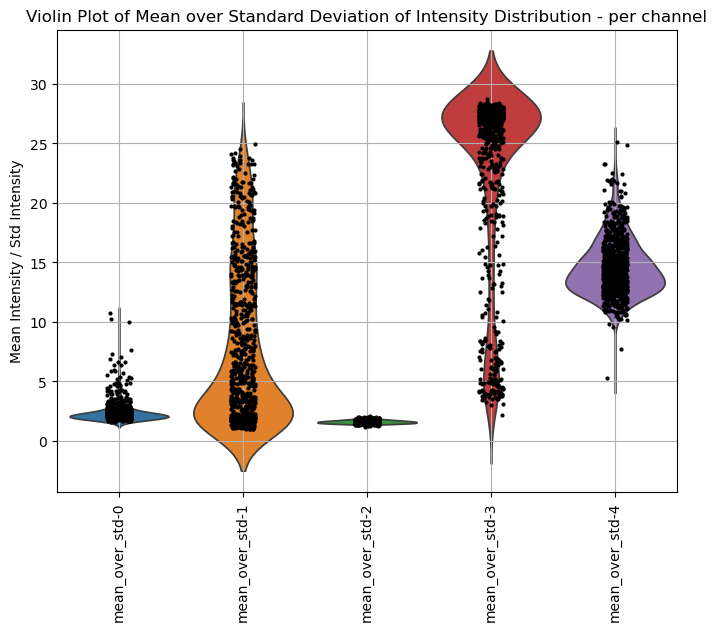

graph saved as 20260318_ACID_mean_over_std_ch.png in Z:\AlessandroUlivi_Data\projects\ACID\develop\260318_QCs\train


In [ ]:
fig6, ax6 = plt.subplots(1,1,figsize=(8,6))

sns.violinplot(data=metadata_df[mean_over_std_column_names], ax=ax6, inner=None)
sns.stripplot(data=metadata_df[mean_over_std_column_names], ax=ax6, color='black', size=3)

ax6.set_title("Violin Plot of Mean over Standard Deviation of Intensity Distribution - per channel")
ax6.set_ylabel("Mean Intensity / Std Intensity")
plt.grid()
plt.xticks(rotation=90)
plt.show()

# save graph
if save_graphs:
    mean_over_std_per_channel_saving_name = f"{datetime.datetime.now().strftime(qc_graphs_date_format)}{save_file_name_separator}{project_name}{save_file_name_separator}{mean_over_std_per_channel_savingword}{qc_graphs_suffix}"
    fig6.savefig(os.path.join(graph_saving_directory, mean_over_std_per_channel_saving_name))
    print(f"graph saved as {mean_over_std_per_channel_saving_name} in {graph_saving_directory}")
else:
    print("graph not saved, set save_graphs to True to save the graph")


#### Display fields of view with min-max MEAN OVER STD

Run the following cell.

Don't modify the following cell.

In [ ]:
# istantiate napari viewer
napari_viewer3 = napari.Viewer()

# visualize quality control metrics using napari
display_high_low_qc(metadata_df,
           napari_viewer=napari_viewer3,
           qc_clm_collection=mean_over_std_column_names,
           fov_clm=fov_column_name,
           ch_measurement_sep=ch_measurement_separator,
           fov_dir=fov_directory,
           channel_ax=channel_axis)


mean_over_std-0
(1024, 1024) (1024, 1024)
mean_over_std-1
(1024, 1024) (1024, 1024)
mean_over_std-2
(1024, 1024) (1024, 1024)
mean_over_std-3
(1024, 1024) (1024, 1024)
mean_over_std-4
(1024, 1024) (1024, 1024)


#### Select field of views to display, for specific channels and around a MEAN OVER STD value

Run the following cell.

Some parts of the following cell should be modified. The parts NOT to modify are under the line ""--- --- --- DON'T MODIFY THE FOLLOWING LINES --- --- ---"

In [ ]:
qc_to_display = "mean_over_std" # string, how it is reported in the graph
channel_to_display = 4 # int, how it is reported in the graph
value_to_display = 5 # int or float
one_sided_range = 5.5 # int or float


# ""--- --- --- DON'T MODIFY THE FOLLOWING LINES --- --- ---"
# select columns
df_to_display = metadata_df[(metadata_df[f"{qc_to_display}{ch_measurement_separator}{channel_to_display}"]>value_to_display-abs(one_sided_range))
                            &
                            (metadata_df[f"{qc_to_display}{ch_measurement_separator}{channel_to_display}"]<value_to_display+abs(one_sided_range))][[fov_column_name, f"{qc_to_display}{ch_measurement_separator}{channel_to_display}"]]



df_to_display


,ome_tif_file_name,mean_over_std-4
187,H7_DENV2_MOI1_30h_fixed_stained_well4_A07p2_F2...,10.268647
374,H7_DENV2_MOI1_30h_fixed_stained_well8_A07p2_E4...,7.696309
556,H7_DENV2_MOI1_40h_fixed_stained_well4_A07p3_C4...,10.297495
562,H7_DENV2_MOI1_40h_fixed_stained_well4_A07p3_D5...,9.825098
563,H7_DENV2_MOI1_40h_fixed_stained_well4_A07p3_D4...,9.548782
564,H7_DENV2_MOI1_40h_fixed_stained_well4_A07p3_D3...,10.163532
571,H7_DENV2_MOI1_40h_fixed_stained_well4_A07p3_E5...,10.214343
879,H7_DENV2_MOI1_40h_fixed_stained_well2_A07p4_G5...,5.267328


#### Display fields of view with targeted MEAN OVER STD values - NOTE: these have been selected in the cell above

Run the following cell.

Don't modify the following cell.

In [ ]:
# istantiate napari viewer
napari_viewer_3 = napari.Viewer()

display_qc(df_to_display = df_to_display,
           napari_viewer=napari_viewer_3,
               metadata_df=metadata_df,
               fov_column_name=fov_column_name,
               fov_directory=fov_directory,
               channel_to_display=channel_to_display,
               channel_axis=channel_axis,
               qc_to_display=qc_to_display,
               ch_measurement_separator=ch_measurement_separator)


#### Define thresholds for flagging fields of view based on MEAN OVER STD

Run the following cell.

Modify the following cell.

In [ ]:
# enter one threshold per channel - fields of view with values above this threshold will be flagged
mean_over_std_lowpass_thresholds = [9,30,2.1,29,24]

# enter one threshold per channel - fields of view with values below this threshold will be flagged
mean_over_std_highpass_thresholds = [1.5,0.9,1,3,8]


#### Visualize MEAN OVER STD values per channel and experiment

Run the following cell.

Modify the following cell.

graph saved as 20260318_ACID_mean_over_std_ch_exp.png in Z:\AlessandroUlivi_Data\projects\ACID\develop\260318_QCs\train


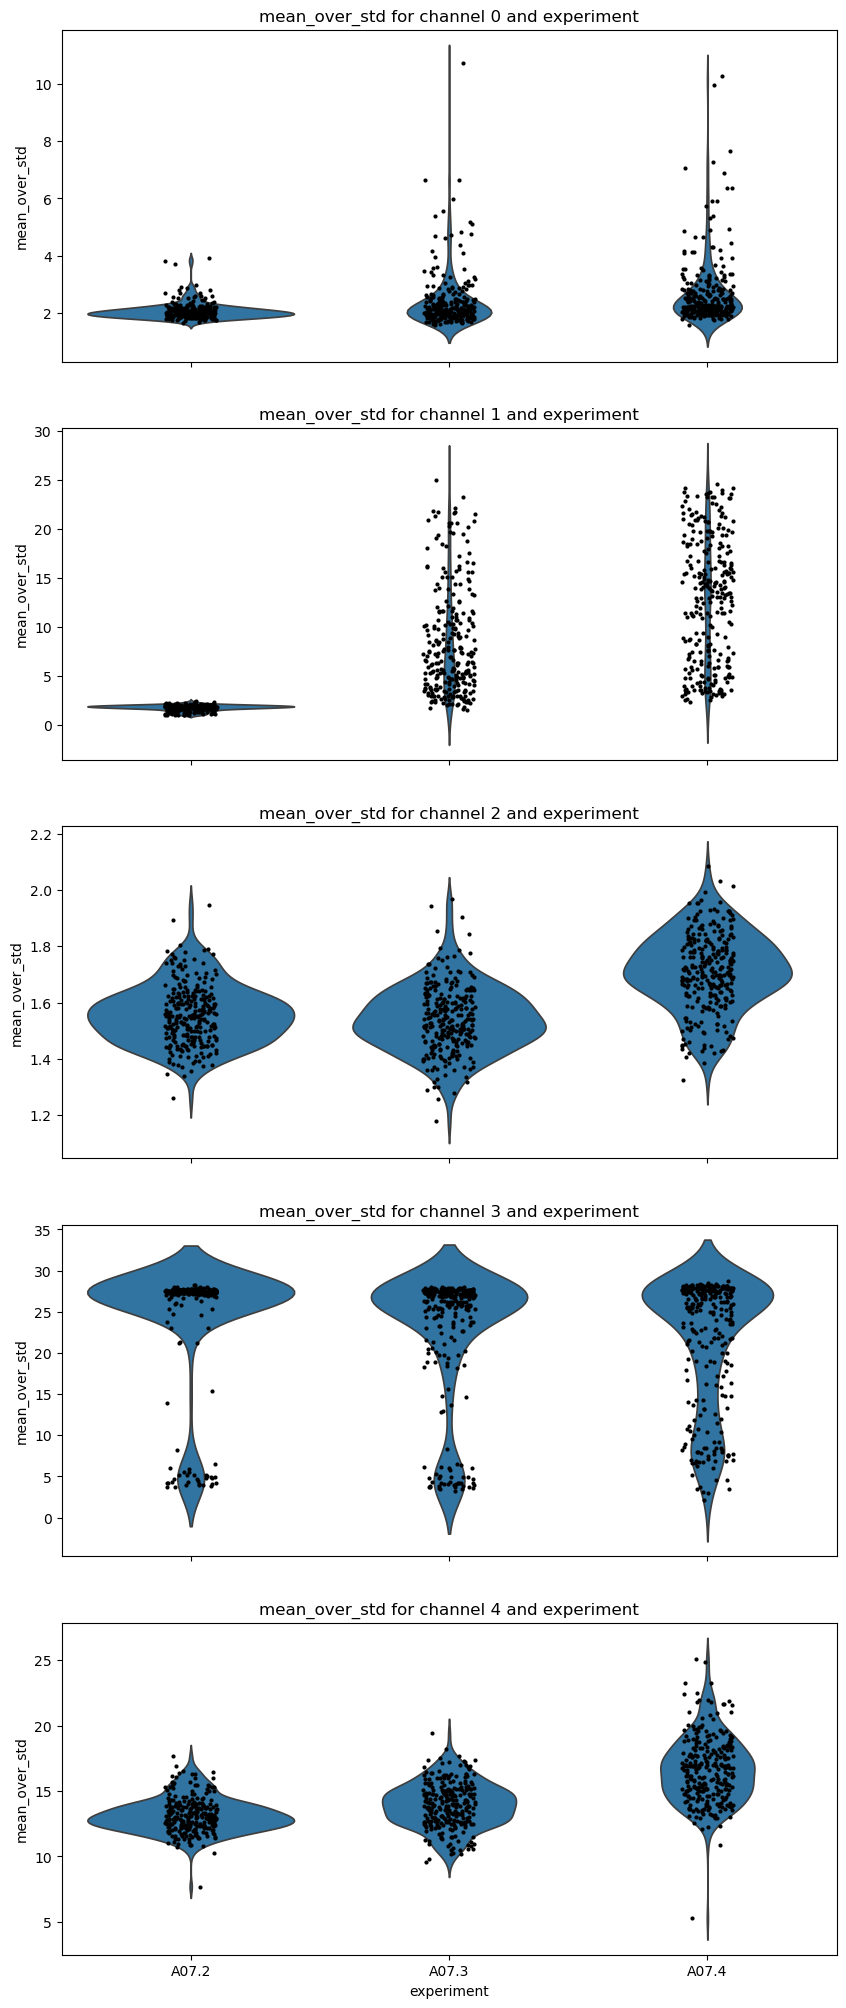

In [ ]:
fig7, ax7 = plt.subplots(num_channels, 1,figsize=(10,5*num_channels), sharex=True, sharey=False)

plot_qc_by_channel_condition(metadata_df=metadata_df,
                             qc_clm=mean_over_std_column_name,
                             condition_clm=experiment_clm,
                             ax=ax7,
                             num_channels=num_channels,
                             ch_measurement_separator=ch_measurement_separator)

# save graph
if save_graphs:
    mean_over_std_per_ch_exp_saving_name = f"{datetime.datetime.now().strftime(qc_graphs_date_format)}{save_file_name_separator}{project_name}{save_file_name_separator}{mean_over_std_per_ch_exp_savingword}{qc_graphs_suffix}"
    fig7.savefig(os.path.join(graph_saving_directory, mean_over_std_per_ch_exp_saving_name))
    print(f"graph saved as {mean_over_std_per_ch_exp_saving_name} in {graph_saving_directory}")
else:
    print("graph not saved, set save_graphs to True to save the graph")


#### Visualize MEAN OVER STD values per channel and well

Run the following cell.

Modify the following cell.

graph saved as 20260318_ACID_mean_over_std_ch_well.png in Z:\AlessandroUlivi_Data\projects\ACID\develop\260318_QCs\train


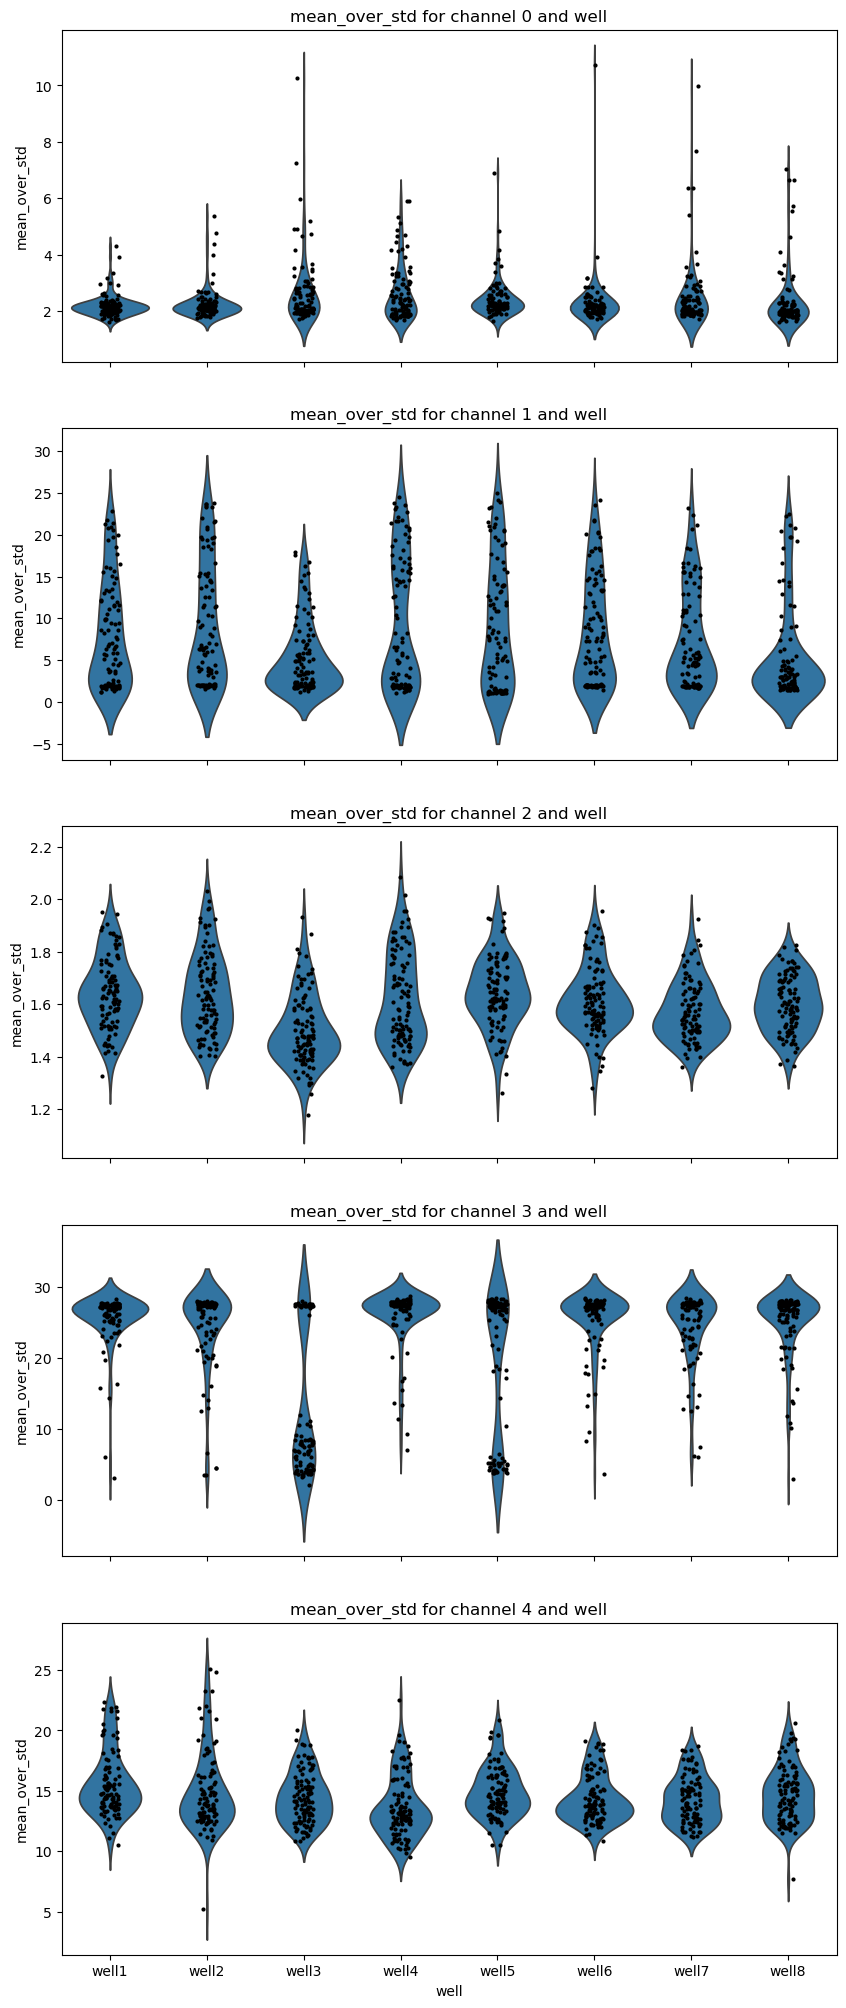

In [ ]:
fig8, ax8 = plt.subplots(num_channels, 1,figsize=(10,5*num_channels), sharex=True, sharey=False)

plot_qc_by_channel_condition(metadata_df=metadata_df,
                             qc_clm=mean_over_std_column_name,
                             condition_clm=well_clm,
                             ax=ax8,
                             num_channels=num_channels,
                             ch_measurement_separator=ch_measurement_separator)

# save graph
if save_graphs:
    mean_over_std_per_ch_well_saving_name = f"{datetime.datetime.now().strftime(qc_graphs_date_format)}{save_file_name_separator}{project_name}{save_file_name_separator}{mean_over_std_per_ch_well_savingword}{qc_graphs_suffix}"
    fig8.savefig(os.path.join(graph_saving_directory, mean_over_std_per_ch_well_saving_name))
    print(f"graph saved as {mean_over_std_per_ch_well_saving_name} in {graph_saving_directory}")
else:
    print("graph not saved, set save_graphs to True to save the graph")


#### Visualize EXTREME INTENSITY PERCENTILE FRACTIONS

Run the following cell.

Don't modify the following cell.

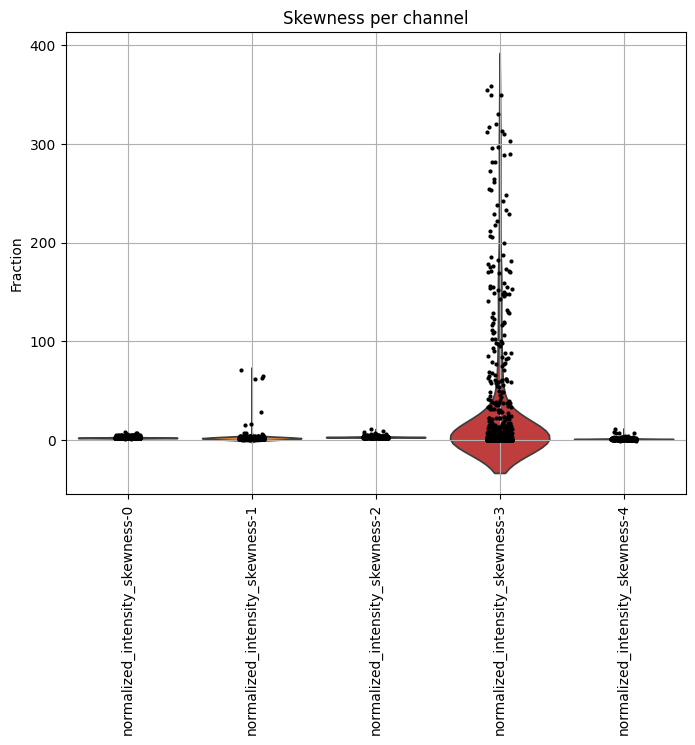

graph saved as 20260427_ACID_perc_fract_ch.png in Z:\AlessandroUlivi_Data\projects\ACID\develop\260421_QCs


In [ ]:
fig3, ax3 = plt.subplots(1,1,figsize=(8,6))

sns.violinplot(data=metadata_df[skewness_column_names], ax=ax3, inner=None)
sns.stripplot(data=metadata_df[skewness_column_names], ax=ax3, color='black', size=3)

ax3.set_title("Skewness per channel")
ax3.set_ylabel("Fraction")


ax3.tick_params(axis='x', labelrotation=90)
ax3.grid()


plt.show()

# save graph
if save_graphs:
    perc_fract_per_channel_saving_name = f"{datetime.datetime.now().strftime(qc_graphs_date_format)}{save_file_name_separator}{project_name}{save_file_name_separator}{perc_fract_per_channel_savingword}{qc_graphs_suffix}"
    fig3.savefig(os.path.join(graph_saving_directory, perc_fract_per_channel_saving_name))
    print(f"graph saved as {perc_fract_per_channel_saving_name} in {graph_saving_directory}")
else:
    print("graph not saved, set save_graphs to True to save the graph")



#### Display fields of view with min-max INTENSITY PERCENTILE FRACTIONS

Run the following cell.

Don't modify the following cell.

In [ ]:
# istantiate napari viewer
napari_viewer1 = napari.Viewer()

# visualize quality control metrics using napari
display_high_low_qc(metadata_df,
           napari_viewer=napari_viewer1,
           qc_clm_collection=skewness_column_names,
           fov_clm=fov_column_name,
           ch_measurement_sep=ch_measurement_separator,
           fov_dir=fov_directory,
           channel_ax=channel_axis)



normalized_intensity_skewness-0
(1024, 1024) (1024, 1024)
normalized_intensity_skewness-1
(1024, 1024) (1024, 1024)
normalized_intensity_skewness-2
(1024, 1024) (1024, 1024)
normalized_intensity_skewness-3
(1024, 1024) (1024, 1024)
normalized_intensity_skewness-4
(1024, 1024) (1024, 1024)


#### Select field of views to display, for specific channels and around a EXTREME INTENSITY PERCENTILE FRACTION value

Run the following cell.

Some parts of the following cell should be modified. The parts NOT to modify are under the line ""--- --- --- DON'T MODIFY THE FOLLOWING LINES --- --- ---"

In [66]:
qc_to_display = "normalized_intensity_skewness" # string, how it is reported in the graph
channel_to_display = 2 # int, how it is reported in the graph
value_to_display = 10 # int or float
one_sided_range = 2 # int or float


# ""--- --- --- DON'T MODIFY THE FOLLOWING LINES --- --- ---"
# select columns
df_to_display = metadata_df[(metadata_df[f"{qc_to_display}{ch_measurement_separator}{channel_to_display}"]>value_to_display-abs(one_sided_range))
                            &
                            (metadata_df[f"{qc_to_display}{ch_measurement_separator}{channel_to_display}"]<value_to_display+abs(one_sided_range))][[fov_column_name, f"{qc_to_display}{ch_measurement_separator}{channel_to_display}"]]

df_to_display


,ome_tif_file_name,normalized_intensity_skewness-2
196,H7_DENV2_MOI1_30h_fixed_stained_well5_A07p2_A1...,8.204424
487,H7_DENV2_MOI1_40h_fixed_stained_well2_A07p3_G5...,8.594252
928,H7_DENV2_MOI1_40h_fixed_stained_well3_A07p4_G5...,10.716903


#### Display fields of view with targeted EXTREME INTENSITY PERCENTILE FRACTION values - NOTE: these have been selected in the cell above

Run the following cell.

Don't modify the following cell.

In [67]:
# istantiate napari viewer
napari_viewer_2 = napari.Viewer()

display_qc(df_to_display = df_to_display,
           napari_viewer=napari_viewer_2,
               metadata_df=metadata_df,
               fov_column_name=fov_column_name,
               fov_directory=fov_directory,
               channel_to_display=channel_to_display,
               channel_axis=channel_axis,
               qc_to_display=qc_to_display,
               ch_measurement_separator=ch_measurement_separator)



#### Define thresholds for flagging fields of view based on EXTREME INTENSITY PERCENTILE FRACTIONS

Run the following cell.

Modify the following cell.

In [ ]:
# enter one threshold per channel - fields of view with values above this threshold will be flagged
bot_perc_lowpass_thresholds = [0.023,0.023,0.022,0.023,0.0205]

# enter one threshold per channel - fields of view with values below this threshold will be flagged
bot_perc_highpass_thresholds = [0.02,0.02,0.02,0.02,0.02]


#### Visualize EXTREME INTENSITY PERCENTILE FRACTION values per channel and experiment plate

Run the following cell.

Modify the following cell.

graph saved as 20260318_ACID_perc_fract_ch_exp.png in Z:\AlessandroUlivi_Data\projects\ACID\develop\260318_QCs\train


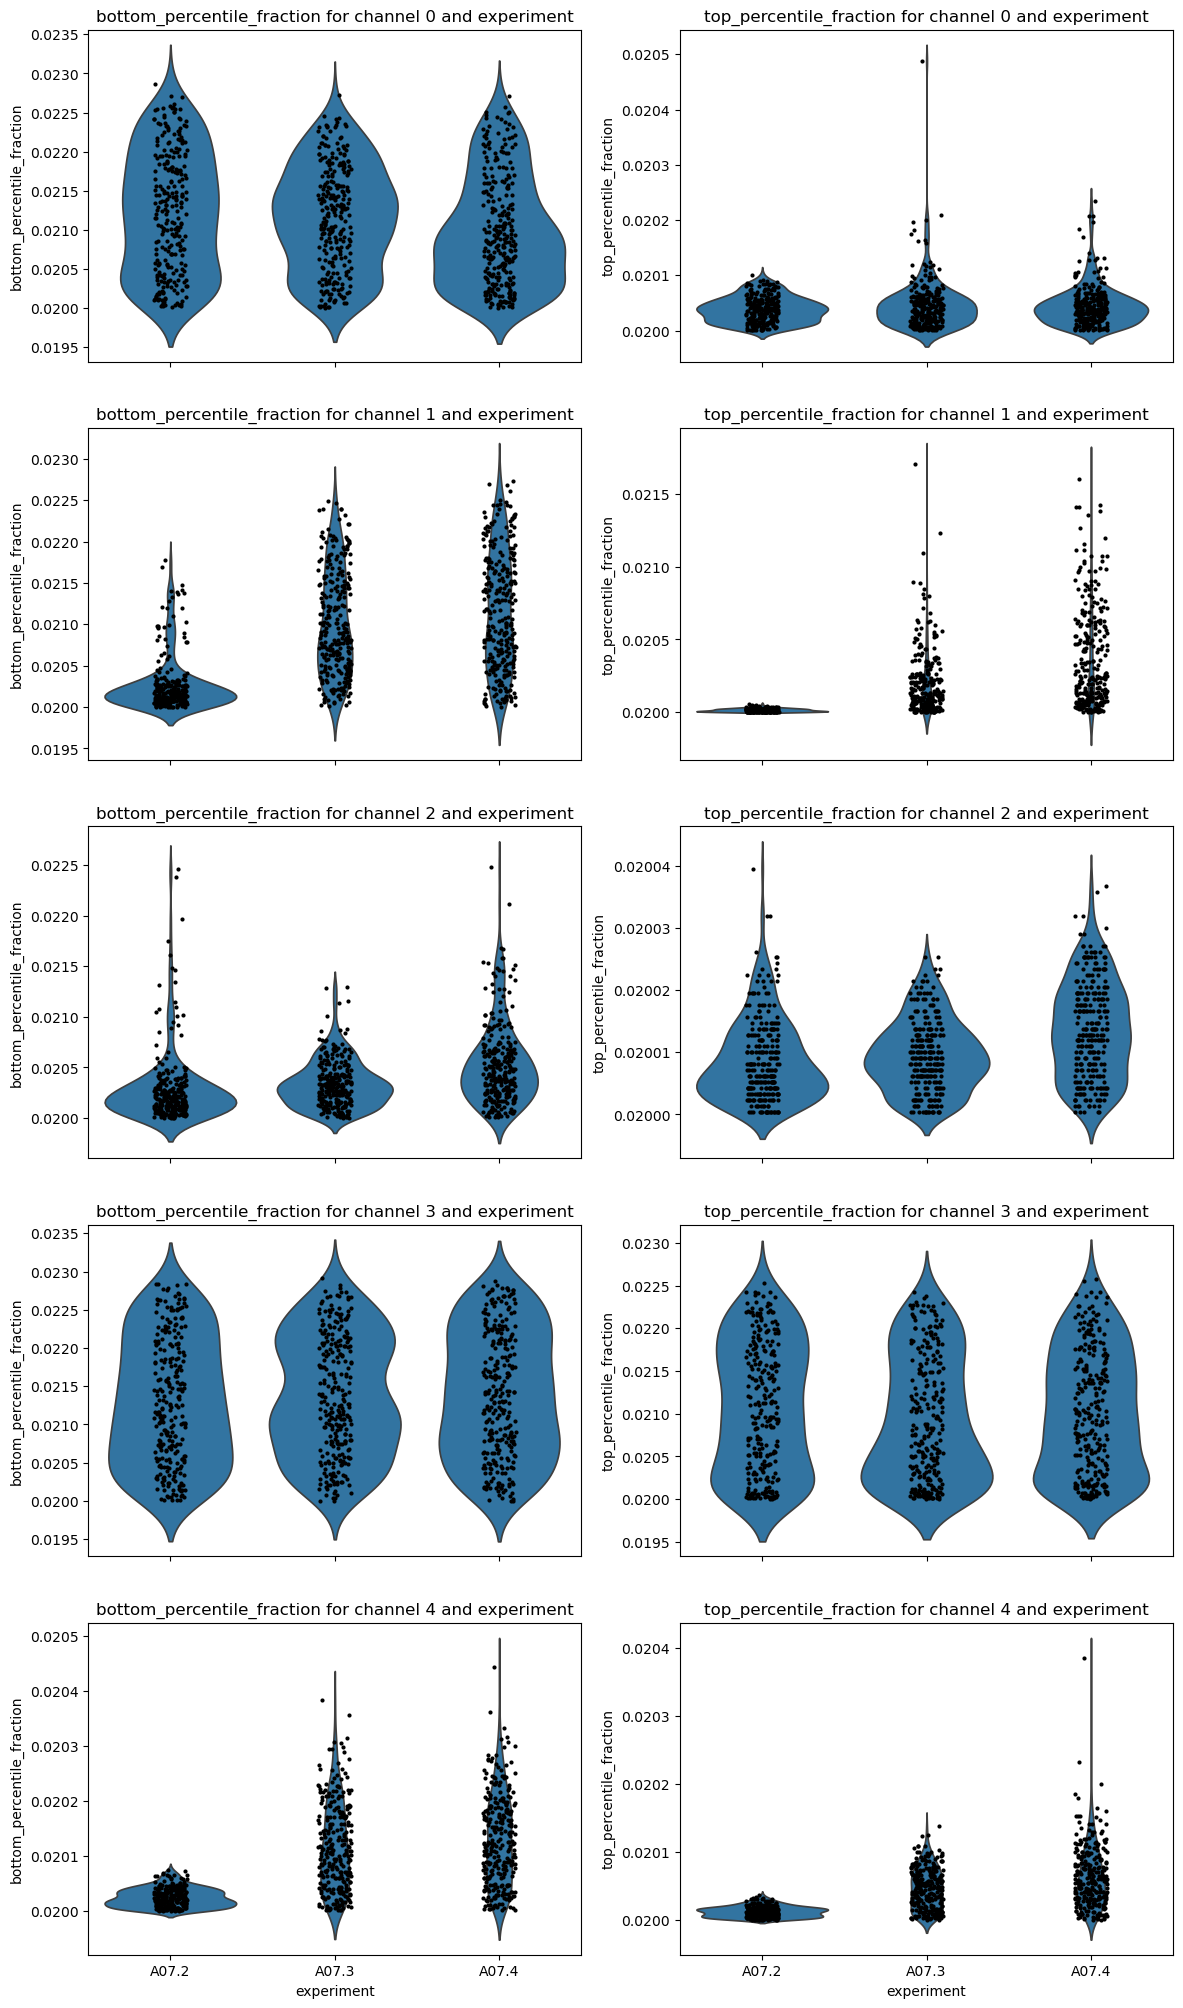

In [145]:
fig4, ax4 = plt.subplots(num_channels, 2, figsize=(14,5*num_channels), sharex=True, sharey=False)

plot_qc_by_channel_condition(metadata_df=metadata_df,
                             qc_clm=bottom_perc_fract_column_name,
                             condition_clm=experiment_clm,
                             ax=ax4[:,0],
                             num_channels=num_channels,
                             ch_measurement_separator=ch_measurement_separator)

plot_qc_by_channel_condition(metadata_df=metadata_df,
                             qc_clm=top_perc_fract_column_name,
                             condition_clm=experiment_clm,
                             ax=ax4[:,1],
                             num_channels=num_channels,
                             ch_measurement_separator=ch_measurement_separator)

# save graph
if save_graphs:
    perc_fract_per_ch_exp_saving_name = f"{datetime.datetime.now().strftime(qc_graphs_date_format)}{save_file_name_separator}{project_name}{save_file_name_separator}{perc_fract_per_ch_exp_savingword}{qc_graphs_suffix}"
    fig4.savefig(os.path.join(graph_saving_directory, perc_fract_per_ch_exp_saving_name))
    print(f"graph saved as {perc_fract_per_ch_exp_saving_name} in {graph_saving_directory}")
else:
    print("graph not saved, set save_graphs to True to save the graph")



#### Visualize EXTREME INTENSITY PERCENTILE FRACTIONS values per channel and well

Run the following cell.

Modify the following cell.

graph saved as 20260318_ACID_perc_fract_ch_well.png in Z:\AlessandroUlivi_Data\projects\ACID\develop\260318_QCs\train


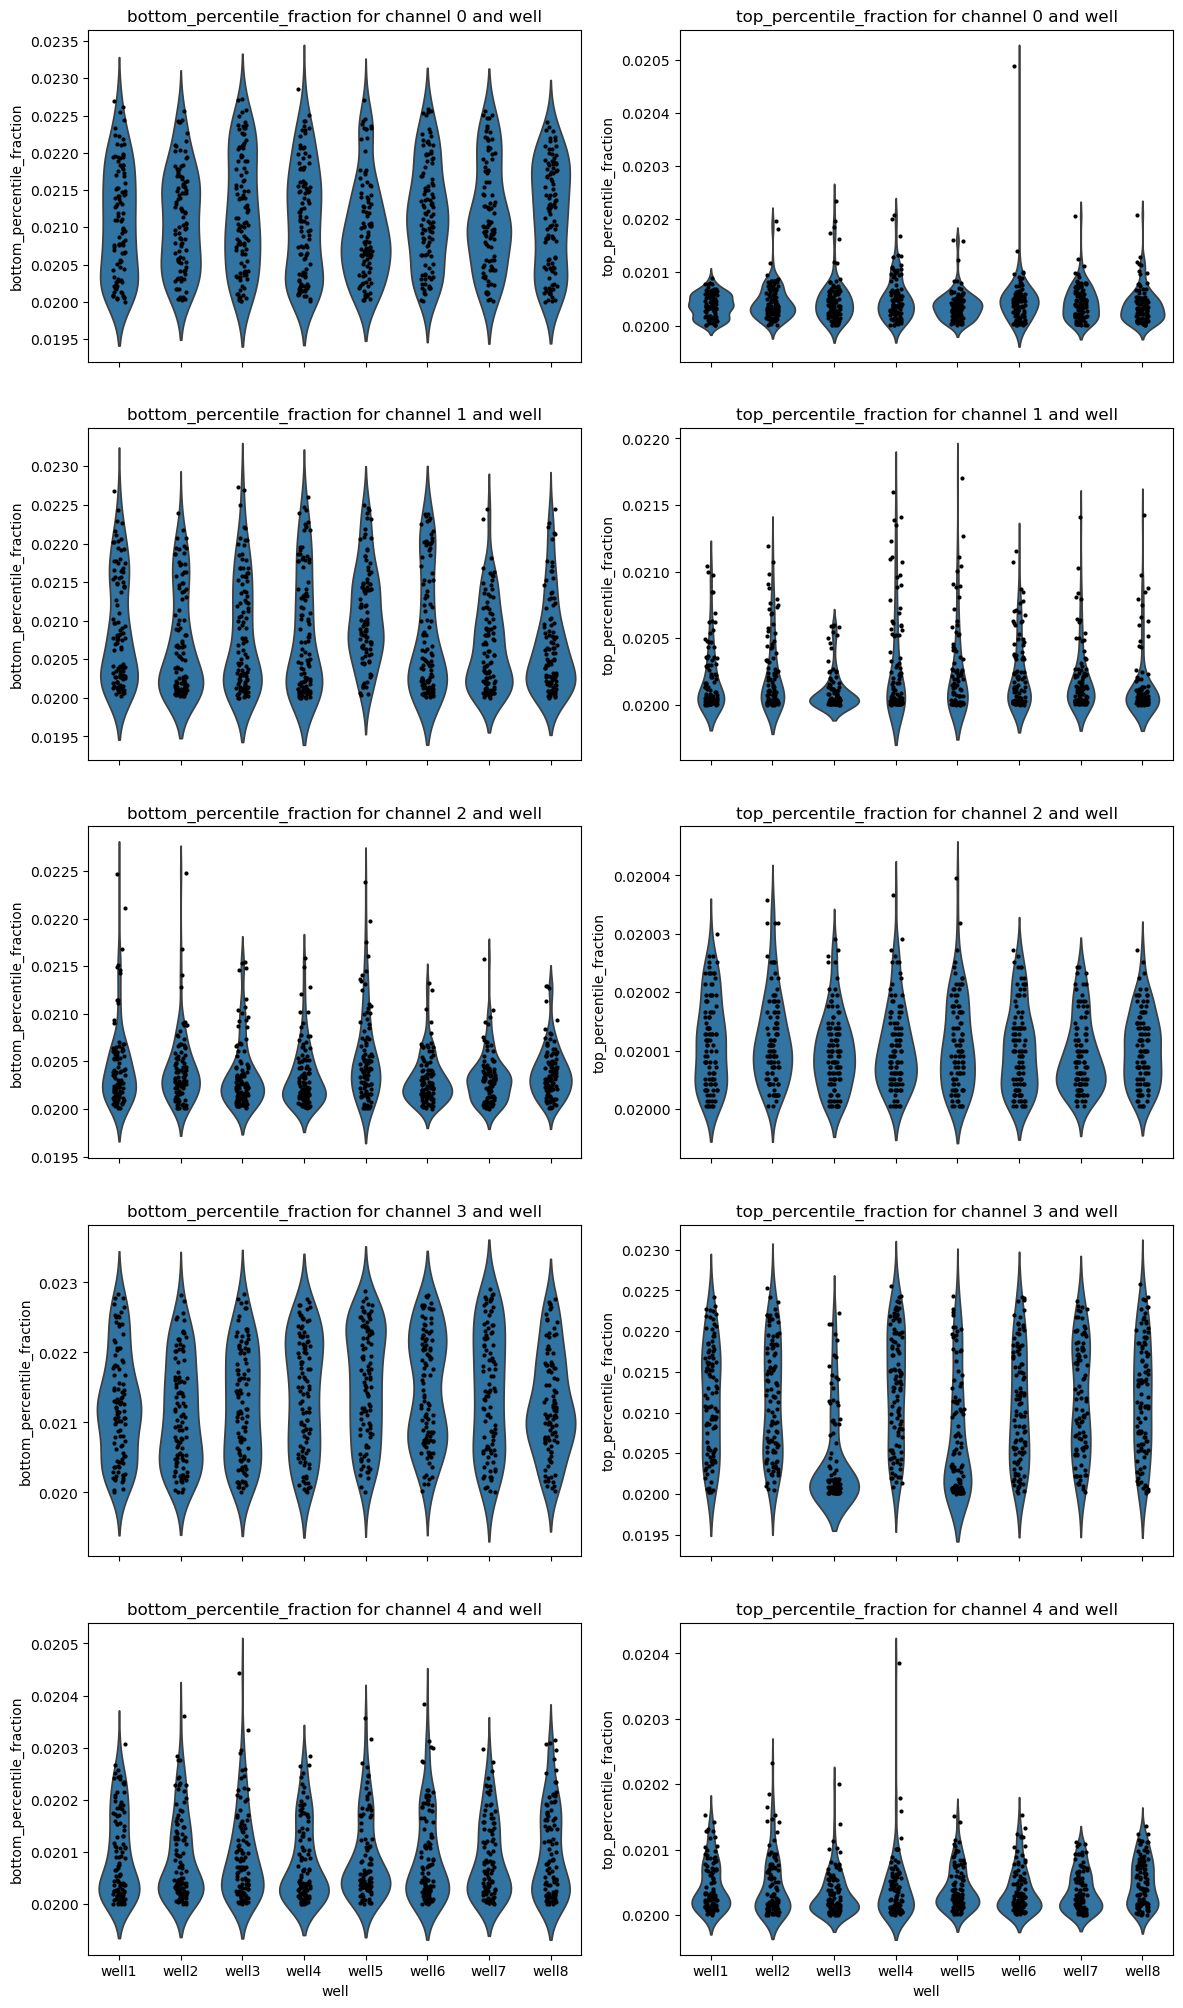

In [146]:
fig5, ax5 = plt.subplots(num_channels, 2, figsize=(14,5*num_channels), sharex=True, sharey=False)

plot_qc_by_channel_condition(metadata_df=metadata_df,
                             qc_clm=bottom_perc_fract_column_name,
                             condition_clm=well_clm,
                             ax=ax5[:,0],
                             num_channels=num_channels,
                             ch_measurement_separator=ch_measurement_separator)

plot_qc_by_channel_condition(metadata_df=metadata_df,
                             qc_clm=top_perc_fract_column_name,
                             condition_clm=well_clm,
                             ax=ax5[:,1],
                             num_channels=num_channels,
                             ch_measurement_separator=ch_measurement_separator)

# save graph
if save_graphs:
    perc_fract_per_ch_well_saving_name = f"{datetime.datetime.now().strftime(qc_graphs_date_format)}{save_file_name_separator}{project_name}{save_file_name_separator}{perc_fract_per_ch_well_savingword}{qc_graphs_suffix}"
    fig5.savefig(os.path.join(graph_saving_directory, perc_fract_per_ch_well_saving_name))
    print(f"graph saved as {perc_fract_per_ch_well_saving_name} in {graph_saving_directory}")
else:
    print("graph not saved, set save_graphs to True to save the graph")



#### Add flag column to the dataset and save the results

Run the following cell.

Don't modify the following cell.

In [251]:
# concatenate QC columns names
qc_column_names = plls_column_names + bottom_perc_fract_column_names + top_perc_fract_column_names + mean_over_std_column_names

# concatenate QC lowpass thresholds
qc_lowpass_thresholds = plls_lowpass_thresholds +  bot_perc_lowpass_thresholds + top_perc_lowpass_thresholds + mean_over_std_lowpass_thresholds

# concatenate QC highpass thresholds
qc_highpass_thresholds = plls_highpass_thresholds + bot_perc_highpass_thresholds + top_perc_highpass_thresholds + mean_over_std_highpass_thresholds

# add flag column
flagged_metadata_df = add_flag_column(df=metadata_df,
                                      lowpass_thres=qc_lowpass_thresholds,
                                      highpass_thres=qc_highpass_thresholds,
                                      cols=qc_column_names,
                                      flag_col=flag_column,
                                      flag_value=flag_value,
                                      ok_value=ok_value)

# save the dataframe
flagged_metadata_saving_name = f"{datetime.datetime.now().strftime(metadata_date_format)}{save_file_name_separator}{project_name}{save_file_name_separator}{metadata_savingword}{save_file_name_separator}{metadata_file_suffix}"
flagged_metadata_df.to_csv(os.path.join(metadata_directory, flagged_metadata_saving_name), index=save_csv_index)


### Save hyperparameters

Run the following cell.

Don't modify the following cell.

In [ ]:
# # collect hyperparameters in a dictionary

hyperparameter_dict = {
'output_directory':output_directory,
'metadata_directory':metadata_directory,
'fov_directory':fov_directory,
'graph_saving_directory':graph_saving_directory,
'metadata_file_name':metadata_file_name,
'save_graphs':save_graphs,
'flag_column':flag_column,
'flag_value':flag_value,
'ok_value':ok_value,
'is_train_column':is_train_column,
'train_val':train_val,
'default_metadata_file_target':default_metadata_file_target,
'default_metadata_file_exclude':default_metadata_file_exclude,
'metadata_from_file_name':metadata_from_file_name,
'metadata_default_separator':metadata_default_separator,
'metadata_default_date_position':metadata_default_date_position,
'metadata_default_date_format':metadata_default_date_format,
'metadata_default_reverse':metadata_default_reverse,
'channel_axis':channel_axis,
'fov_column_name':fov_column_name,
'null_value':null_value,
'plls_column_name':plls_column_name,
'low_percentile':low_percentile,
'high_percentile':high_percentile,
'bottom_perc_fract_column_name':bottom_perc_fract_column_name,
'top_perc_fract_column_name':top_perc_fract_column_name,
'mean_over_std_column_name':mean_over_std_column_name,
'ch_measurement_separator':ch_measurement_separator,
'save_file_name_separator':save_file_name_separator,
'project_name':project_name,
'save_csv_index':save_csv_index,
'metadata_date_format':metadata_date_format,
'metadata_savingword':metadata_savingword,
'metadata_file_suffix':metadata_file_suffix,
'hyperparameters_date_format':hyperparameters_date_format,
'hyperparameters_savingword':hyperparameters_savingword,
'hyperparameters_file_suffix':hyperparameters_file_suffix,
'secondary_output_directory':secondary_output_directory,
'exist_ok':exist_ok,
'plls_lowpass_thresholds':plls_lowpass_thresholds,
'bot_perc_lowpass_thresholds':bot_perc_lowpass_thresholds,
'top_perc_lowpass_thresholds':top_perc_lowpass_thresholds,
'mean_over_std_lowpass_thresholds':mean_over_std_lowpass_thresholds,
'plls_highpass_thresholds':plls_highpass_thresholds,
'bot_perc_highpass_thresholds':bot_perc_highpass_thresholds,
'top_perc_highpass_thresholds':top_perc_highpass_thresholds,
'median_smooth':median_smooth,
'footprint':footprint,
'median_kwargs':median_kwargs,
'mean_over_std_highpass_thresholds':mean_over_std_highpass_thresholds,
'well_clm':well_clm,
'experiment_clm':experiment_clm,
'qc_well_x_axis_column_name':qc_well_x_axis_column_name,
'qc_experiment_x_axis_column_name':qc_experiment_x_axis_column_name,
'qc_graphs_date_format':qc_graphs_date_format,
'qc_graphs_suffix':qc_graphs_suffix,
'plls_per_channel_savingword':plls_per_channel_savingword,
'plls_per_channel_experiment_savingword':plls_per_channel_experiment_savingword,
'plls_per_channel_well_savingword':plls_per_channel_well_savingword,
'perc_fract_per_channel_savingword':perc_fract_per_channel_savingword,
'perc_fract_per_ch_exp_savingword':perc_fract_per_ch_exp_savingword,
'perc_fract_per_ch_well_savingword':perc_fract_per_ch_well_savingword,
'mean_over_std_per_channel_savingword':mean_over_std_per_channel_savingword,
'mean_over_std_per_ch_exp_savingword':mean_over_std_per_ch_exp_savingword,
'mean_over_std_per_ch_well_savingword':mean_over_std_per_ch_well_savingword
}


# save hyperparameters
hyperparameter_series = pd.Series(hyperparameter_dict)
hyperparameter_saving_name = f"{datetime.datetime.now().strftime(hyperparameters_date_format)}{save_file_name_separator}{project_name}{save_file_name_separator}{hyperparameters_savingword}{save_file_name_separator}{hyperparameters_file_suffix}"
hyperparameter_series.to_csv(os.path.join(secondary_output_directory,hyperparameter_saving_name), index=save_csv_index)

